# Examples

In [5]:
from pathlib import Path
from obspy import read_events
import obspy, utils, os
from pathlib import Path
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

## Plot waveforms from Finnish dataset

### Plot event waveforms
Load explosion event waveforms from the local dataset and plot it against the true P and S arrival times from the labels file.

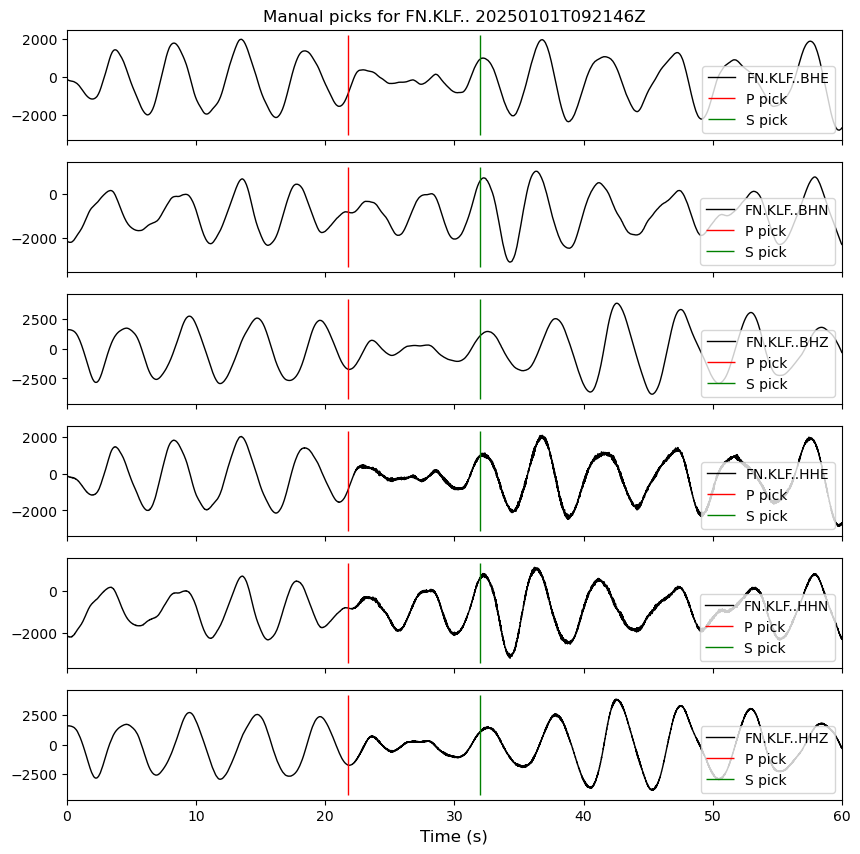

In [11]:
max_rows = 1 # Maximum number of labels to read and plot

# Read the true P and S arrival times from labels.csv  
df_event_labels = pd.read_csv(utils.FILENAME_Y_EQ, nrows=max_rows)

# Iterate through each label, loading waveforms and plotting the true P and S arrival times on them
for row in df_event_labels.itertuples():

    network_code, station_code, win_start, win_end = utils.parse_label_filename(row.file_name)
    p_time = utils.to_utc_or_none(row.p_arrival_time)
    s_time = utils.to_utc_or_none(row.s_arrival_time)
    
    # Load the corresponding waveform from the locally-stored dataset
    st = utils.load_stream(win_start, win_end, network_code, station_code, dir=utils.WAVEFORM_EQ_DIR)

    if st:
        # If the waveform exists in the dataset, plot it with its true P and S arrival times
        utils.plot_traces(st,
                        ptime=p_time,
                        stime=s_time,
                        title=f"Manual picks for {network_code}.{station_code}.. {win_start}",
                        # figname=Path(utils.VIS_DIR) / f"{network_code} {station_code} {win_start}.png", # If set, save plot as file
                        showf=True) # If set, show plot 

### Plot noise waveforms from local dataset

Load noise waveforms from the local dataset

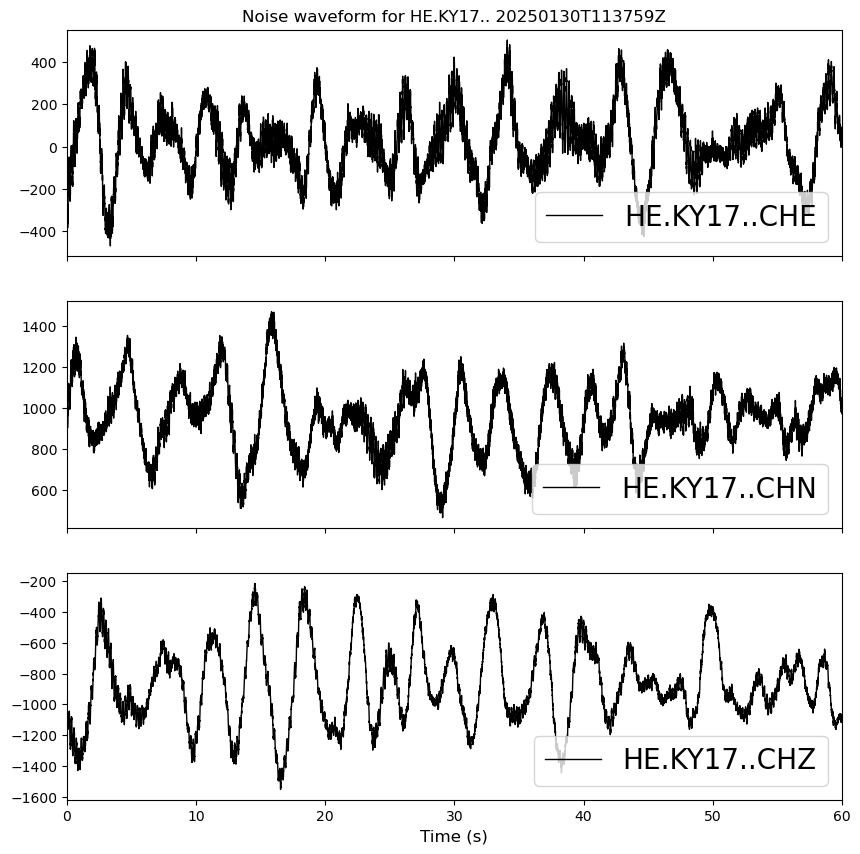

In [12]:
max_rows = 1 # Maximum number of labels to read and plot

# Read the true P and S arrival times from labels.csv  
df_noise_labels = pd.read_csv(utils.FILENAME_Y_NOISE, nrows=max_rows)

# Iterate through each label, loading waveforms and plotting the true P and S arrival times on them
for row in df_noise_labels.itertuples():

    network_code, station_code, win_start, win_end = utils.parse_label_filename(row.file_name)
    
    # Load the corresponding waveform from the locally-stored dataset
    st = utils.load_stream(win_start, win_end, network_code, station_code, dir=utils.WAVEFORM_NOISE_DIR)
    p_time = utils.to_utc_or_none(row.p_arrival_time) # Placed here to demonstrate there are no picks
    s_time = utils.to_utc_or_none(row.s_arrival_time) # Placed here to demonstrate there are no picks
    
    if st:
        # If the waveform exists in the dataset, plot it with its true P and S arrival times
        utils.plot_traces(st,
                        ptime=p_time,
                        stime=s_time,
                        title=f"Noise waveform for {network_code}.{station_code}.. {win_start}",
                        figname=Path(utils.VIS_DIR) / f"{network_code} {station_code} {win_start}.png", # If set, save plot as file
                        showf=True) # If set, show plot 

# Opening miniSEED files
miniSEED files contain earthquake waveforms. 

A data stream is identified by a XX.XXXXX.XX.XXX string, which is a concatenation of station ID and stream ID. 

Station ID is in the form NET_S:
* NET is network code (1-2 chars)
* STA is station code (1-5 chars). 

Stream ID is in the form LOC_B_S_SS
* LOC is location code (2 chars, but left empty if value is 00): used to uniquely identify different streams in a station 
* B_S_SS is chanel code (3 chars): 
  * B is the band code which identifies the general sample rate
  * S is the source code that identifies the instrument type
  * SS is the subsource code that identifies the orientation of the sensor (Z for vertical, N for north-south, E for east-west).

[source 1](https://docs.fdsn.org/projects/seedlink/en/latest/protocol.html#station-id-and-stream-id:~:text=RFC7159%5D%20format.-,Station%20ID%20and%20stream%20ID,band%20code%2C%20S%20is%20source%20code%20and%20SS%20is%20subsource%20code.,-Station%20ID%20and), [source 2](https://seismology.resif.fr/type-of-data/#:~:text=miniSEED%20data%20is%C2%A0%20identified%20by%20standardized%20codes%20for%20networks%20(groups%20of%20stations)%2C%20stations%20(groups%20of%20channels)%2C%20location%20and%20channels.%20This%20information%20is%20present%20in%20the%20file%20header.), [Data channel search tool](https://ds.iris.edu/ds/nodes/dmc/tools/data_channels/#HHZ), [GEOFON GFZ FDSWS DatasSelect Web Service](http://geofon.gfz-potsdam.de/fdsnws/dataselect/1/) for downloading mseed files to try.